# PCA (Principle Component Analysis)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [14]:
iris = load_iris()
x = pd.DataFrame(iris.data)
y = iris.target
sc = StandardScaler()
x_scaled = sc.fit_transform(x)
print(x_scaled.shape)
# PCA
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)
print(x_pca.shape) # reduce the input features into 2 
print("The varience ratio", pca.explained_variance_ratio_)
print(pca.components_)

(150, 4)
(150, 2)
The varience ratio [0.72962445 0.22850762]
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


Text(0.5, 1.0, 'PCA for IRIS DATA')

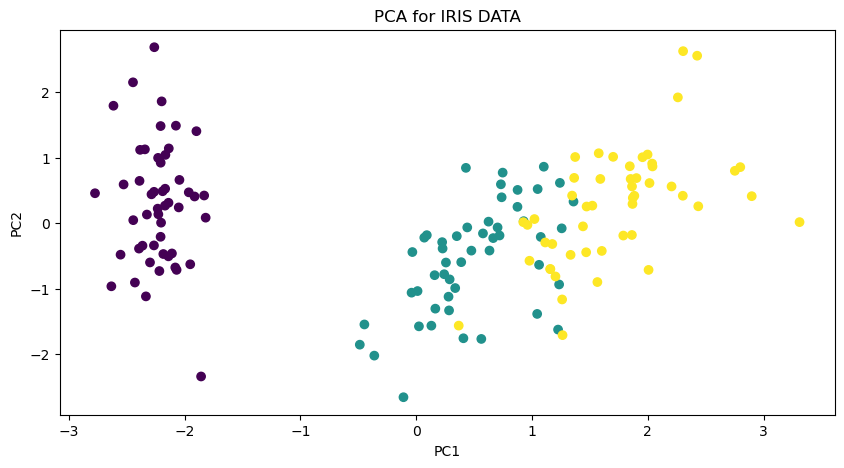

In [22]:
plt.figure(figsize=(10,5))
plt.scatter(x=x_pca[:,0], y = x_pca[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA for IRIS DATA")

# Anamoly Detection Using DBSCAN

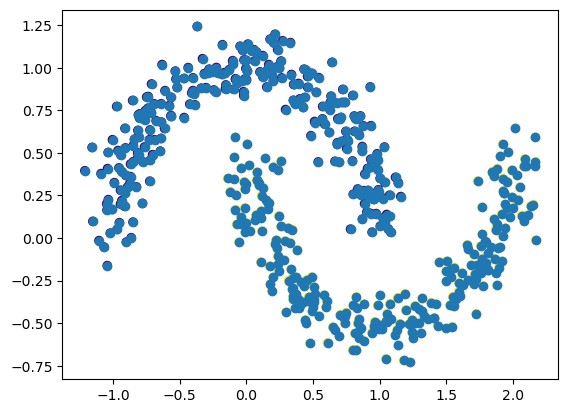

In [36]:
# anamoly dection using DBSCAN
x,y = make_moons(n_samples=500, noise =0.1, random_state=42)
plt.scatter(x=x[:,0], y = x[:,1], c=y)
x_scaled = sc.fit_transform(x)
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(x_scaled)
plt.scatter(x=x[:,0], y = x[:,1])


# Anamoly Detection Using Isolation Forest

The numbers of outliers are 270
The numbers of normal points are 6646


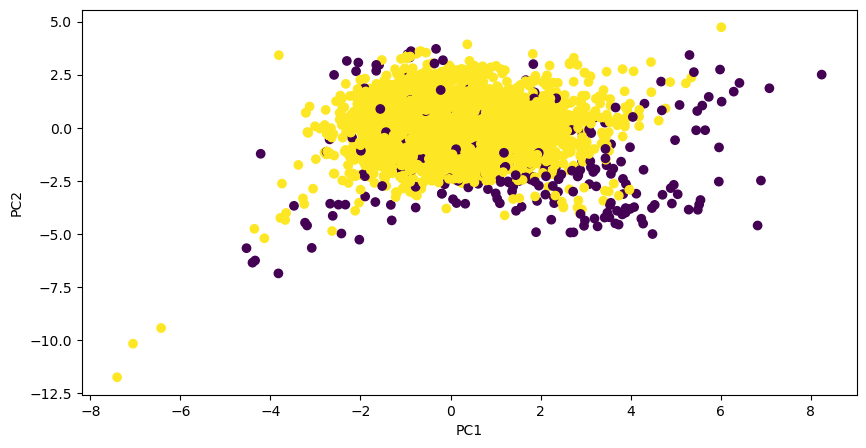

In [42]:
from sklearn.ensemble import IsolationForest
data = pd.read_csv("thyroid_dataset.csv")
data.head()
x = data.drop("Outlier_label", axis = 1)
y = data["Outlier_label"]
x_scaled = sc.fit_transform(x)
isl = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
labels = isl.fit_predict(x_scaled)
# for visualization
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
plt.figure(figsize=(10,5))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.scatter(x_pca[:,0],x_pca[:,1], c = labels)
n_outliers = np.sum(labels ==-1)
n_normal = np.sum(labels ==1)
print("The numbers of outliers are", n_outliers)
print("The numbers of normal points are", n_normal)


# LOF (Local Outlier Factor)

The numbers of outliers are 270
The numbers of normal points are 6646


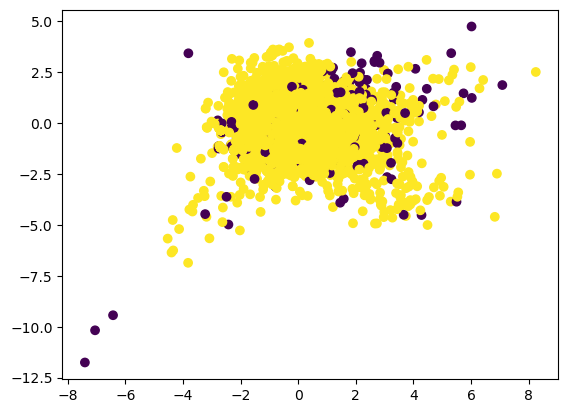

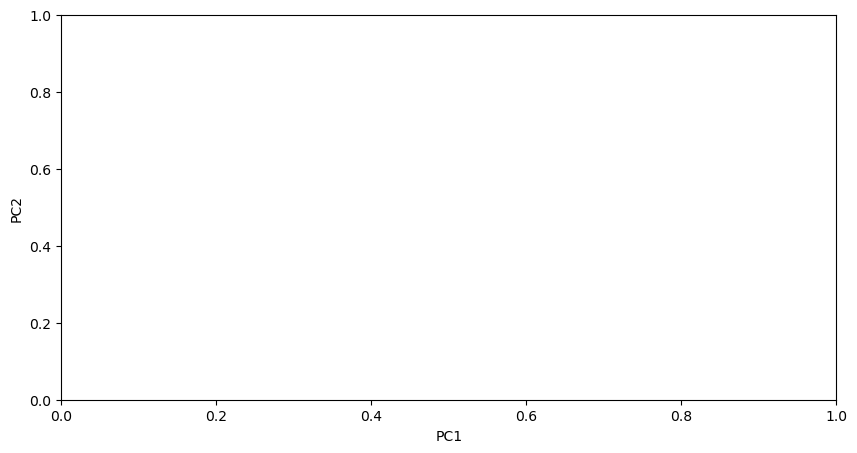

In [47]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(contamination=0.036)
lebels = lof.fit_predict(x_scaled)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
plt.scatter(x_pca[:,0],x_pca[:,1], c = lebels)
plt.figure(figsize=(10,5))
plt.xlabel("PC1")
plt.ylabel("PC2")
n_outliers = np.sum(labels ==-1)
n_normal = np.sum(labels ==1)
print("The numbers of outliers are", n_outliers)
print("The numbers of normal points are", n_normal)